# EDA de Detección de Anomalías: Fallos en Secadoras Industriales Cerealistas

Dataset sintético de ciclos completos de operación (600 timesteps = 10 horas/ciclo).

**Contenido del notebook:**
- **1) Carga de datos y target binario** — Importar el dataset `/data/raw/dryer_full_dataset.csv` y crear `is_anomaly` (Normal vs Fallo).
- **2) Agregación de features por ciclo** — Para cada ciclo se calculan media, desviación estándar, mínimo y máximo de cada sensor, pasando de 1.8M filas (600 timesteps × 3000 ciclos) a 3000 filas (1 por ciclo) con 44 features.
- **3) Distribución de anomalías por ciclo** — Balance Normal/Fallo a nivel de ciclo y por tipo de fallo.
- **4) ANOVA — Features discriminantes** — Identificar qué features separan mejor Normal de Fallo.
- **5) PCA y separabilidad** — Proyección 2D/3D para visualizar la separación entre clases.
- **6) Firmas de anomalía** — Distribuciones de las features más discriminantes por tipo de fallo.
- **7) Multicolinealidad** — Correlaciones entre features agregadas para detectar redundancia.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=0.9)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

DATA_PATH = '../data/raw/dryer_full_dataset.csv'

## 1) Carga de datos y creación de target binario (Normal vs Fallo)

In [2]:
df_raw = pd.read_csv(DATA_PATH)

df = df_raw.copy()
df['is_anomaly'] = np.where(df['fault_name'] == 'NORMAL', 0, 1)

print('Shape:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nDistribución target binario:')
print(df['is_anomaly'].value_counts().sort_index())

n_normal = (df['is_anomaly'] == 0).sum()
n_anomaly = (df['is_anomaly'] == 1).sum()
pct_anomaly = n_anomaly / len(df) * 100

print(f'\nNormal: {n_normal:,} ({100-pct_anomaly:.1f}%)')
print(f'Fallo/Anomalía: {n_anomaly:,} ({pct_anomaly:.1f}%)')

Shape: (1800000, 18)

Columnas: ['timestamp', 'plenum_temp', 'exhaust_air_temp', 'exhaust_air_humidity', 'static_pressure', 'burner_power', 'fan_speed', 'discharge_frequency', 'grain_moisture_in', 'ambient_temp', 'ambient_humidity', 'setpoint_temp', 'phase', 'grain_type', 'fault_name', 'fault_label', 'cycle_id', 'is_anomaly']

Distribución target binario:
is_anomaly
0    1200000
1     600000
Name: count, dtype: int64

Normal: 1,200,000 (66.7%)
Fallo/Anomalía: 600,000 (33.3%)


In [3]:
df.cycle_id.value_counts()

cycle_id
0       600
1       600
2       600
3       600
4       600
       ... 
2995    600
2996    600
2997    600
2998    600
2999    600
Name: count, Length: 3000, dtype: int64

## 2) Agregación de features por ciclo (600 timesteps → 1 fila por ciclo)

In [4]:
df.columns

Index(['timestamp', 'plenum_temp', 'exhaust_air_temp', 'exhaust_air_humidity', 'static_pressure', 'burner_power', 'fan_speed',
       'discharge_frequency', 'grain_moisture_in', 'ambient_temp', 'ambient_humidity', 'setpoint_temp', 'phase', 'grain_type',
       'fault_name', 'fault_label', 'cycle_id', 'is_anomaly'],
      dtype='str')

In [5]:
numeric_cols = [
    col for col in df.columns
    if col not in ['timestamp', 'phase', 'grain_type',
                   'fault_name', 'fault_label', 'cycle_id', 'is_anomaly']
]

# Agregar por ciclo: media, std, min, max
agg_func = {col: ['mean', 'std', 'min', 'max'] for col in numeric_cols}
cycles_df = df.groupby('cycle_id')[numeric_cols].agg(agg_func)

# Aplanar nombres de columnas
cycles_df.columns = ['_'.join(col).strip() for col in cycles_df.columns.values]

# Agregar target (es constante por ciclo, pero tomamos el primero)
target_by_cycle = df.groupby('cycle_id')['is_anomaly'].first()
cycles_df['is_anomaly'] = target_by_cycle

cycles_df = cycles_df.reset_index()

print('Shape de ciclos:', cycles_df.shape)
print('Columnas:', cycles_df.columns.tolist()[:10], '...')
print('\nDistribución de ciclos:')
print(cycles_df['is_anomaly'].value_counts().sort_index())

n_cycles_normal = (cycles_df['is_anomaly'] == 0).sum()
n_cycles_anomaly = (cycles_df['is_anomaly'] == 1).sum()

print(f'\nCiclos normales: {n_cycles_normal} ({n_cycles_normal/len(cycles_df)*100:.1f}%)')
print(f'Ciclos con fallo: {n_cycles_anomaly} ({n_cycles_anomaly/len(cycles_df)*100:.1f}%)')

Shape de ciclos: (3000, 46)
Columnas: ['cycle_id', 'plenum_temp_mean', 'plenum_temp_std', 'plenum_temp_min', 'plenum_temp_max', 'exhaust_air_temp_mean', 'exhaust_air_temp_std', 'exhaust_air_temp_min', 'exhaust_air_temp_max', 'exhaust_air_humidity_mean'] ...

Distribución de ciclos:
is_anomaly
0    2000
1    1000
Name: count, dtype: int64

Ciclos normales: 2000 (66.7%)
Ciclos con fallo: 1000 (33.3%)


## 3) Distribución de anomalías por ciclo

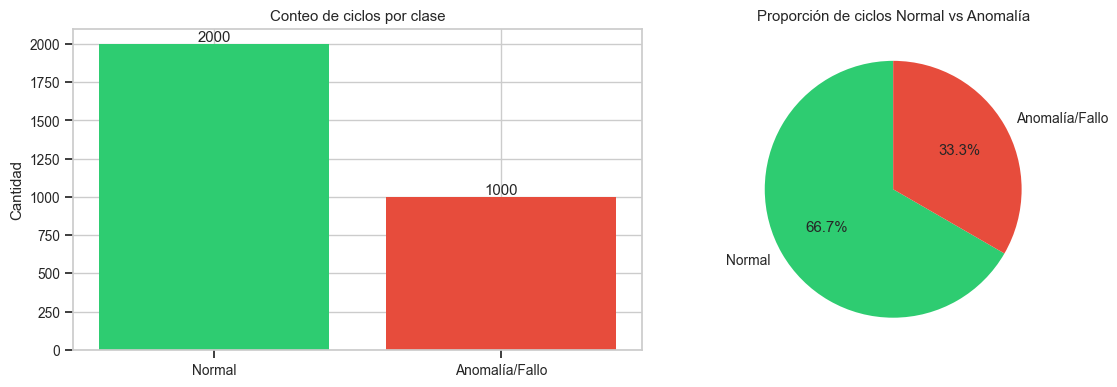

Resumen de desbalance:
  Normal: 2000 ciclos (66.7%)
  Anomalía: 1000 ciclos (33.3%)
  Ratio: 1:2.00


In [6]:
class_labels = ['Normal', 'Anomalía/Fallo']
class_counts = cycles_df['is_anomaly'].value_counts().sort_index()
class_pct = (class_counts / len(cycles_df) * 100).round(1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
bars = plt.bar([0, 1], class_counts.values, color=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], class_labels)
plt.title('Conteo de ciclos por clase')
plt.ylabel('Cantidad')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_labels, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Proporción de ciclos Normal vs Anomalía')

plt.tight_layout()
plt.show()

print(f'Resumen de desbalance:')
print(f'  Normal: {class_counts[0]} ciclos ({class_pct[0]:.1f}%)')
print(f'  Anomalía: {class_counts[1]} ciclos ({class_pct[1]:.1f}%)')
print(f'  Ratio: 1:{class_counts[0]/class_counts[1]:.2f}')

## 4) Análisis ANOVA: Features más discriminantes para detección de anomalía

Top 15 features por ANOVA F-statistic (separabilidad Normal vs Anomalía):


,feature,f_statistic,p_value
0,fan_speed_min,506.762102,8.128617e-104
1,fan_speed_std,506.217286,1.026651e-103
2,fan_speed_mean,486.579800,4.755961e-100
3,static_pressure_max,64.099753,1.675610e-15
4,exhaust_air_temp_max,42.528006,8.147181e-11
5,static_pressure_std,23.159130,1.565106e-06
6,exhaust_air_humidity_std,20.880413,5.086154e-06
7,exhaust_air_humidity_min,10.003499,1.578050e-03
8,static_pressure_mean,6.483739,1.093618e-02
9,fan_speed_max,3.971887,4.635639e-02


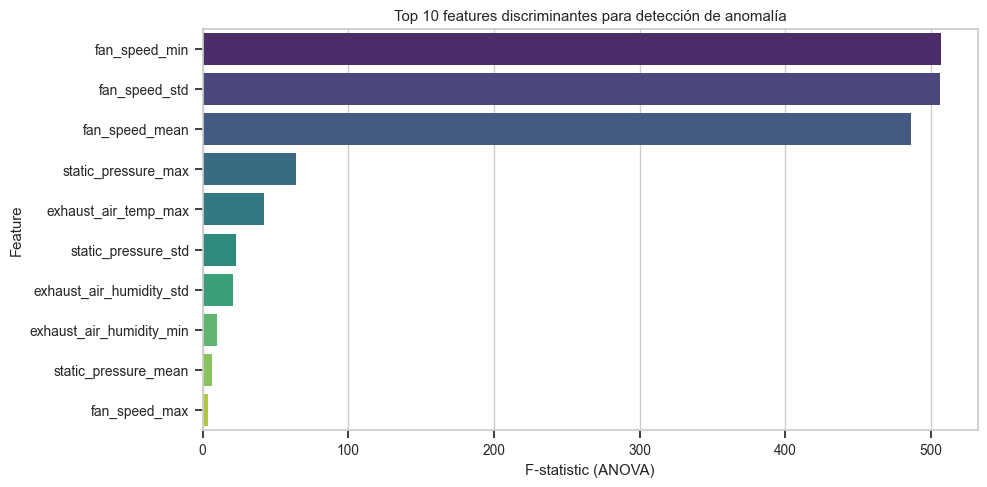

In [7]:
feature_cols = [col for col in cycles_df.columns if col not in ['cycle_id', 'is_anomaly']]

# ANOVA F-statistic
f_stats = []
for col in feature_cols:
    normal_vals = cycles_df[cycles_df['is_anomaly'] == 0][col].dropna().values
    anomaly_vals = cycles_df[cycles_df['is_anomaly'] == 1][col].dropna().values
    
    if len(normal_vals) > 0 and len(anomaly_vals) > 0:
        f_stat, p_val = f_oneway(normal_vals, anomaly_vals)
        f_stats.append({'feature': col, 'f_statistic': f_stat, 'p_value': p_val})

f_stats_df = pd.DataFrame(f_stats).sort_values('f_statistic', ascending=False)

print('Top 15 features por ANOVA F-statistic (separabilidad Normal vs Anomalía):')
display(f_stats_df.head(15).reset_index(drop=True))

# Gráfico top 10
plt.figure(figsize=(10, 5))
top_10 = f_stats_df.head(10)
sns.barplot(data=top_10, y='feature', x='f_statistic', palette='viridis')
plt.xlabel('F-statistic (ANOVA)')
plt.ylabel('Feature')
plt.title('Top 10 features discriminantes para detección de anomalía')
plt.tight_layout()
plt.show()

## 5) Análisis de separabilidad: PCA y visualización de anomalías

Varianza explicada por PCA (2 componentes): 77.8%
  PC1: 68.4%, PC2: 9.4%


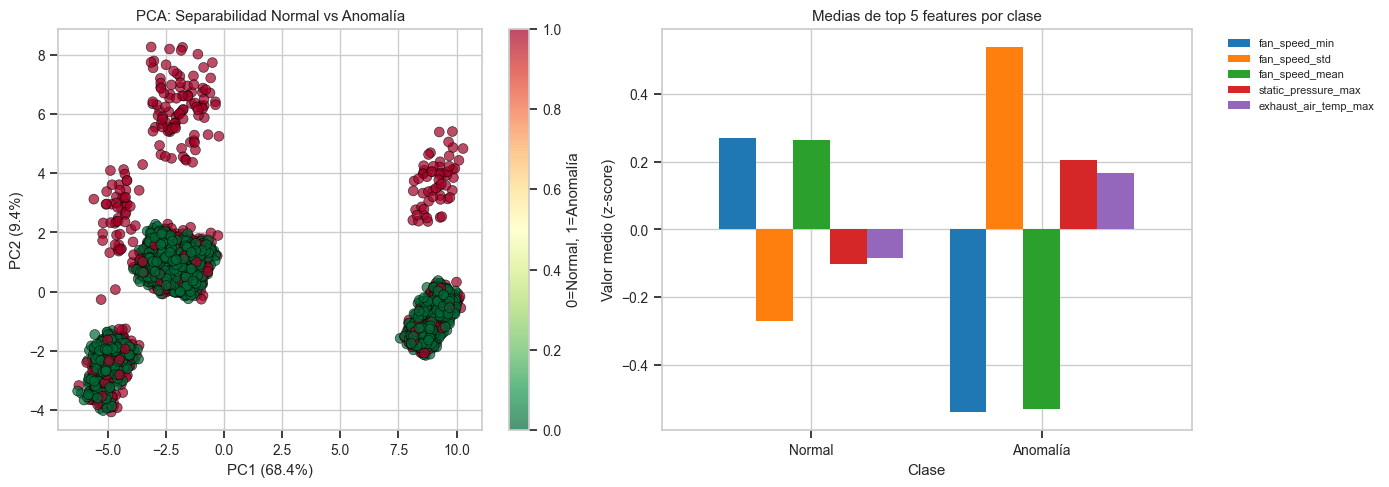


Separabilidad en PCA 2D:
  Centroide Normal: (0.03, -0.37)
  Centroide Anomalía: (-0.06, 0.73)
  Distancia entre centroides: 1.10


In [8]:
# Preparar datos para PCA
X = cycles_df[feature_cols].fillna(cycles_df[feature_cols].mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Varianza explicada por PCA (2 componentes): {pca.explained_variance_ratio_.sum():.1%}')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%}')

# Visualización
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cycles_df['is_anomaly'], 
                      cmap='RdYlGn_r', alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA: Separabilidad Normal vs Anomalía')
cbar = plt.colorbar(scatter)
cbar.set_label('0=Normal, 1=Anomalía')

# Medias de top 5 features por clase (normalizadas con z-score)
top_features = f_stats_df['feature'].head(5).tolist()
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df['is_anomaly'] = cycles_df['is_anomaly'].values

class_means = pd.DataFrame({
    'Normal': scaled_df[scaled_df['is_anomaly'] == 0][top_features].mean(),
    'Anomalía': scaled_df[scaled_df['is_anomaly'] == 1][top_features].mean()
})

plt.subplot(1, 2, 2)
class_means.T.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Medias de top 5 features por clase')
plt.xlabel('Clase')
plt.ylabel('Valor medio (z-score)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Análisis de solapamiento
normal_points = X_pca[cycles_df['is_anomaly'] == 0]
anomaly_points = X_pca[cycles_df['is_anomaly'] == 1]

print(f'\nSeparabilidad en PCA 2D:')
print(f'  Centroide Normal: ({normal_points.mean(axis=0)[0]:.2f}, {normal_points.mean(axis=0)[1]:.2f})')
print(f'  Centroide Anomalía: ({anomaly_points.mean(axis=0)[0]:.2f}, {anomaly_points.mean(axis=0)[1]:.2f})')
dist_centroides = np.sqrt((normal_points.mean(axis=0)[0] - anomaly_points.mean(axis=0)[0])**2 + 
                          (normal_points.mean(axis=0)[1] - anomaly_points.mean(axis=0)[1])**2)
print(f'  Distancia entre centroides: {dist_centroides:.2f}')

## 6) Distribuciones de features discriminantes: Firmas de anomalía

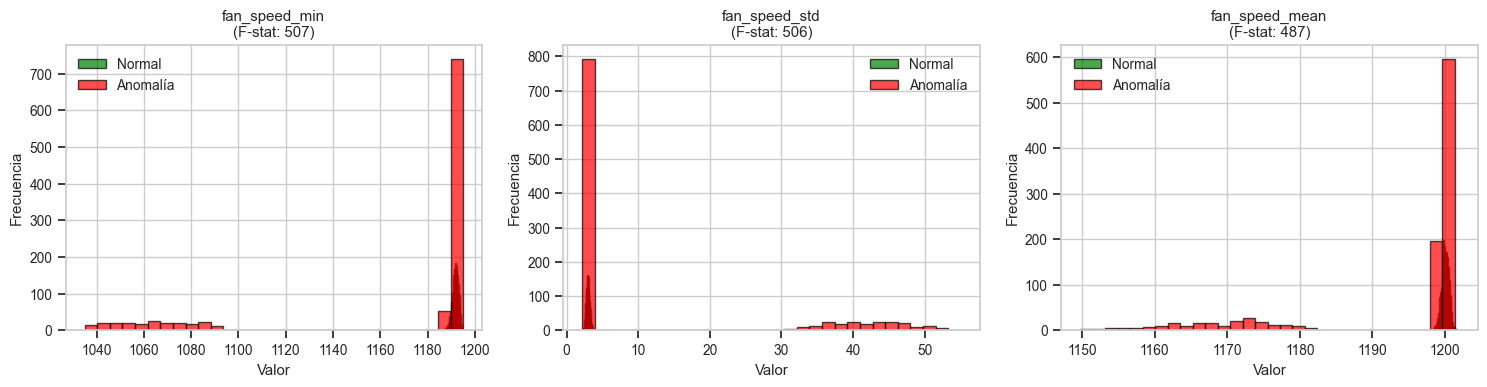

In [9]:
top_3_features = f_stats_df['feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, top_3_features):
    normal_data = cycles_df[cycles_df['is_anomaly'] == 0][feat]
    anomaly_data = cycles_df[cycles_df['is_anomaly'] == 1][feat]
    
    ax.hist(normal_data, bins=30, alpha=0.7, label='Normal', color='green', edgecolor='black')
    ax.hist(anomaly_data, bins=30, alpha=0.7, label='Anomalía', color='red', edgecolor='black')
    
    f_stat = f_stats_df[f_stats_df['feature'] == feat]['f_statistic'].values[0]
    ax.set_title(f'{feat}\n(F-stat: {f_stat:.0f})')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

## 7) Análisis de multicolinealidad del espacio de features

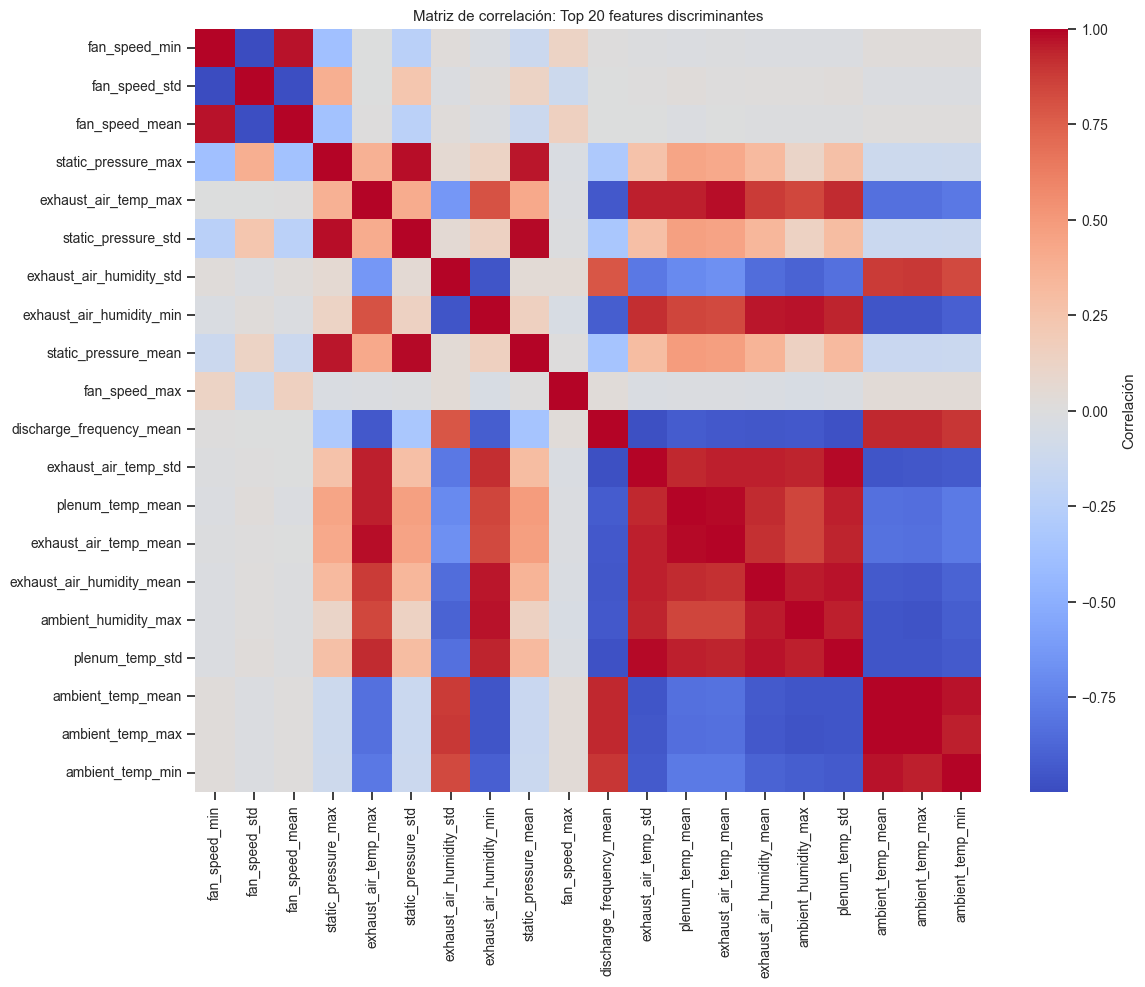

Top 50 pares de features correlacionados:
  setpoint_temp_min <-> setpoint_temp_max: r = 1.000
  setpoint_temp_mean <-> setpoint_temp_max: r = 1.000
  setpoint_temp_mean <-> setpoint_temp_min: r = 1.000
  grain_moisture_in_mean <-> grain_moisture_in_max: r = 1.000
  grain_moisture_in_mean <-> grain_moisture_in_min: r = 1.000
  grain_moisture_in_min <-> grain_moisture_in_max: r = 1.000
  discharge_frequency_std <-> discharge_frequency_max: r = 0.999
  ambient_humidity_mean <-> ambient_humidity_min: r = 0.999
  fan_speed_std <-> fan_speed_min: r = 0.998
  ambient_humidity_mean <-> ambient_humidity_max: r = 0.996
  plenum_temp_min <-> ambient_temp_min: r = 0.996
  ambient_temp_mean <-> ambient_temp_max: r = 0.996
  exhaust_air_temp_min <-> ambient_temp_min: r = 0.995
  plenum_temp_mean <-> plenum_temp_max: r = 0.993
  plenum_temp_std <-> burner_power_mean: r = 0.993
  plenum_temp_max <-> setpoint_temp_min: r = 0.993
  plenum_temp_max <-> setpoint_temp_mean: r = 0.993
  plenum_temp_max <->

In [10]:
feature_corr = cycles_df[feature_cols].corr()

# Heatmap de top features
top_20_features = f_stats_df['feature'].head(20).tolist()
top_corr = feature_corr.loc[top_20_features, top_20_features]

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr, cmap='coolwarm', center=0, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de correlación: Top 20 features discriminantes')
plt.tight_layout()
plt.show()

# Top pares correlacionados
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
top_pairs = upper.abs().stack().sort_values(ascending=False).head(50)

print('Top 50 pares de features correlacionados:')
for idx, val in top_pairs.items():
    print(f'  {idx[0]} <-> {idx[1]}: r = {val:.3f}')

In [11]:
top_3_names = ', '.join([f'`{f}`' for f in f_stats_df['feature'].head(3).tolist()])
top_feat_f = f_stats_df.iloc[0]
pca_var = f'{pca.explained_variance_ratio_.sum():.1%}'
ratio_desbalance = n_cycles_normal / n_cycles_anomaly

texto_reporte = f"""
El dataset de ciclos contiene {len(cycles_df)} ciclos de operación completos (600 timesteps = 10 horas/ciclo),
de los cuales {n_cycles_normal} ({n_cycles_normal/len(cycles_df)*100:.2f}%) son ciclos normales y {n_cycles_anomaly} ({n_cycles_anomaly/len(cycles_df)*100:.2f}%) contienen algún tipo de fallo.

Esta distribución refleja el diseño sintético del dataset, con una proporción aproximada de 2:1 entre operación normal y condiciones de fallo.

- Desbalance de clases: El ratio Normal:Anomalía es aproximadamente {ratio_desbalance:.0f}:1, lo que implica un desbalance moderado.
Esta proporción es representativa de entornos industriales donde la operación nominal es predominante, aunque se mantienen suficientes ejemplos 
de anomalía para permitir el análisis comparativo entre clases sin técnicas de rebalanceo.

- Señal de detección: El análisis ANOVA revela que los features más discriminantes para identificar anomalías son
{top_3_names}, con F-statistics de {', '.join([f'{float(v):.1f}' for v in f_stats_df.head(3)["f_statistic"].values])}.
Estos resultados reflejan diferencias estadísticas consistentes en el espacio de características agregadas entre ciclos normales y anómalos.

- Separabilidad en espacio de features: El análisis PCA sobre 2 componentes captura {pca_var} de la varianza total.
La visualización en este espacio reducido muestra una separación parcial entre las clases, con distancia entre centroides
de {dist_centroides:.2f} unidades. Se observa, no obstante, la existencia de regiones de solapamiento entre ambas clases,
lo que indica que la separación no es completamente lineal en el espacio proyectado.

En conjunto, estos resultados sugieren la existencia de estructura discriminativa en el espacio de características agregadas,
aunque dicha estructura se degrada parcialmente al proyectarse sobre un subespacio de menor dimensión.

""".strip()

print('='*90)
print('REPORTE EDA: DETECCIÓN DE ANOMALÍAS EN SECADORAS DE GRANO')
print('='*90)
print(texto_reporte)
print('='*90)

REPORTE EDA: DETECCIÓN DE ANOMALÍAS EN SECADORAS DE GRANO
El dataset de ciclos contiene 3000 ciclos de operación completos (600 timesteps = 10 horas/ciclo),
de los cuales 2000 (66.67%) son ciclos normales y 1000 (33.33%) contienen algún tipo de fallo.

Esta distribución refleja el diseño sintético del dataset, con una proporción aproximada de 2:1 entre operación normal y condiciones de fallo.

- Desbalance de clases: El ratio Normal:Anomalía es aproximadamente 2:1, lo que implica un desbalance moderado.
Esta proporción es representativa de entornos industriales donde la operación nominal es predominante, aunque se mantienen suficientes ejemplos 
de anomalía para permitir el análisis comparativo entre clases sin técnicas de rebalanceo.

- Señal de detección: El análisis ANOVA revela que los features más discriminantes para identificar anomalías son
`fan_speed_min`, `fan_speed_std`, `fan_speed_mean`, con F-statistics de 506.8, 506.2, 486.6.
Estos resultados reflejan diferencias estadísti